In [10]:
# STEP 1 — Imports and Dataset Path Setup (Corrected)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("✅ TensorFlow version:", tf.__version__)

# === CORRECT DATASET PATH ===
DATASET_DIR = r"C:\Users\user\Desktop\jupyter notebook\garbage\garbage-dataset"

# Verify dataset
print("📂 Dataset exists:", os.path.exists(DATASET_DIR))
print("📁 Folders inside dataset directory:")
for f in os.listdir(DATASET_DIR):
    print("  -", f)


✅ TensorFlow version: 2.20.0
📂 Dataset exists: True
📁 Folders inside dataset directory:
  - battery
  - biological
  - cardboard
  - clothes
  - glass
  - metal
  - paper
  - plastic
  - shoes
  - trash


In [11]:
# STEP 2 — Create Training and Validation Generators
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

# ImageDataGenerators (with preprocessing + data augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    validation_split       = 0.2,          # 80% train / 20% validation
    rotation_range         = 20,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    shear_range            = 0.05,
    zoom_range             = 0.15,
    horizontal_flip        = True,
    fill_mode              = "nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    validation_split       = 0.2
)

# Create training generator
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    subset      = "training",
    shuffle     = True,
    seed        = SEED
)

# Create validation generator
val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    subset      = "validation",
    shuffle     = False,
    seed        = SEED
)

# Number of classes
num_classes = len(train_generator.class_indices)

print("\n✅ Classes found:", train_generator.class_indices)
print("✅ Number of classes:", num_classes)
print("✅ Training samples:", train_generator.samples)
print("✅ Validation samples:", val_generator.samples)


Found 15813 images belonging to 10 classes.
Found 3949 images belonging to 10 classes.

✅ Classes found: {'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}
✅ Number of classes: 10
✅ Training samples: 15813
✅ Validation samples: 3949


Class names: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


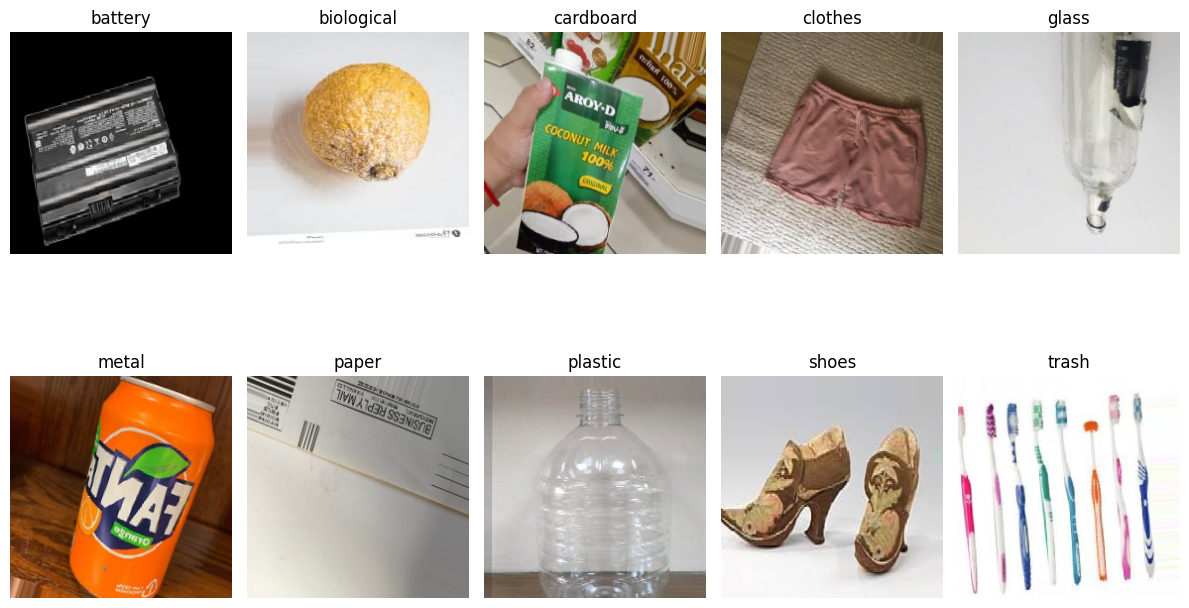

In [12]:
# STEP 3 — Visualize Sample Images from the Training Set
import matplotlib.pyplot as plt
import numpy as np

# Get class labels
class_names = list(train_generator.class_indices.keys())
print("Class names:", class_names)

# Show one image per class
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names[:10]):  # limit to 10 if you have many classes
    batch = next(train_generator)  # get one batch of images and labels
    images, labels = batch[0], batch[1]
    
    # Find index of current class in this batch (if exists)
    indices = np.where(np.argmax(labels, axis=1) == i)[0]
    if len(indices) > 0:
        img = images[indices[0]]  # pick first image of that class
        img = (img + 1.0) / 2.0   # reverse preprocessing for display
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()


In [13]:
# STEP 4 — Build the CNN Model using Transfer Learning (MobileNetV2)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Make sure num_classes is defined from Step 2
print("Number of classes:", num_classes)

# Load MobileNetV2 base model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze the base model initially
base_model.trainable = False

# Build the classification head
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Create model
model = keras.Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model summary
model.summary()


Number of classes: 10


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,589,514 (9.88 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Training steps per epoch: 494
Validation steps: 123
Training samples: 15813 Validation samples: 3949
Computed class weights: {0: np.float64(2.091666666666667), 1: np.float64(1.981578947368421), 2: np.float64(1.083082191780822), 3: np.float64(0.37102299389957766), 4: np.float64(0.6456921192323397), 5: np.float64(1.9378676470588236), 6: np.float64(1.1765625), 7: np.float64(0.9957808564231738), 8: np.float64(0.9995575221238938), 9: np.float64(2.0861477572559366)}


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7547 - loss: 0.8847
Epoch 1: val_accuracy improved from None to 0.90523, saving model to saved_models\best_mobilenetv2_frozen.h5


494/494 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.8241 - loss: 0.6307 - val_accuracy: 0.9052 - val_loss: 0.2976 - learning_rate: 0.0010
Epoch 2/20
  1/494 ━━━━━━━━━━━━━━━━━━━━ 3:46 460ms/step - accuracy: 0.8750 - loss: 0.5974

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

494/494 ━━━━━━━━━━━━━━━━━━━━ 471s 952ms/step - accuracy: 0.9152 - loss: 0.2700 - val_accuracy: 0.9296 - val_loss: 0.2277 - learning_rate: 5.0000e-04
Epoch 14/20
  1/494 ━━━━━━━━━━━━━━━━━━━━ 3:43 454ms/step - accuracy: 0.8750 - loss: 0.5811
Epoch 14: val_accuracy improved from 0.92962 to 0.92988, saving model to saved_models\best_mobilenetv2_frozen.h5


494/494 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.8750 - loss: 0.5811 - val_accuracy: 0.9299 - val_loss: 0.2280 - learning_rate: 5.0000e-04
Epoch 15/20
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.9198 - loss: 0.2490
Epoch 15: val_accuracy improved from 0.92988 to 0.93039, saving model to saved_models\best_mobilenetv2_frozen.h5


494/494 ━━━━━━━━━━━━━━━━━━━━ 480s 971ms/step - accuracy: 0.9191 - loss: 0.2473 - val_accuracy: 0.9304 - val_loss: 0.2267 - learning_rate: 5.0000e-04
Epoch 16/20
  1/494 ━━━━━━━━━━━━━━━━━━━━ 3:24 415ms/step - accuracy: 0.9688 - loss: 0.0907
Epoch 16: val_accuracy did not improve from 0.93039
494/494 ━━━━━━━━━━━━━━━━━━━━ 55s 111ms/step - accuracy: 0.9688 - loss: 0.0907 - val_accuracy: 0.9299 - val_loss: 0.2269 - learning_rate: 5.0000e-04
Epoch 17/20
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.9217 - loss: 0.2433
Epoch 17: val_accuracy did not improve from 0.93039
494/494 ━━━━━━━━━━━━━━━━━━━━ 447s 906ms/step - accuracy: 0.9212 - loss: 0.2438 - val_accuracy: 0.9278 - val_loss: 0.2284 - learning_rate: 5.0000e-04
Epoch 18/20
  1/494 ━━━━━━━━━━━━━━━━━━━━ 3:41 449ms/step - accuracy: 0.8438 - loss: 0.4851
Epoch 18: val_accuracy did not improve from 0.93039

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
494/494 ━━━━━━━━━━━━━━━━━━━━ 55s 111ms/step - acc

494/494 ━━━━━━━━━━━━━━━━━━━━ 451s 913ms/step - accuracy: 0.9243 - loss: 0.2220 - val_accuracy: 0.9332 - val_loss: 0.2149 - learning_rate: 2.5000e-04
Epoch 20/20
  1/494 ━━━━━━━━━━━━━━━━━━━━ 3:23 412ms/step - accuracy: 0.9062 - loss: 0.2144
Epoch 20: val_accuracy did not improve from 0.93318
494/494 ━━━━━━━━━━━━━━━━━━━━ 55s 112ms/step - accuracy: 0.9062 - loss: 0.2144 - val_accuracy: 0.9329 - val_loss: 0.2148 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 20.


Saved final model to: saved_models\mobilenetv2_frozen_final.h5
Best checkpoint saved to: saved_models\best_mobilenetv2_frozen.h5


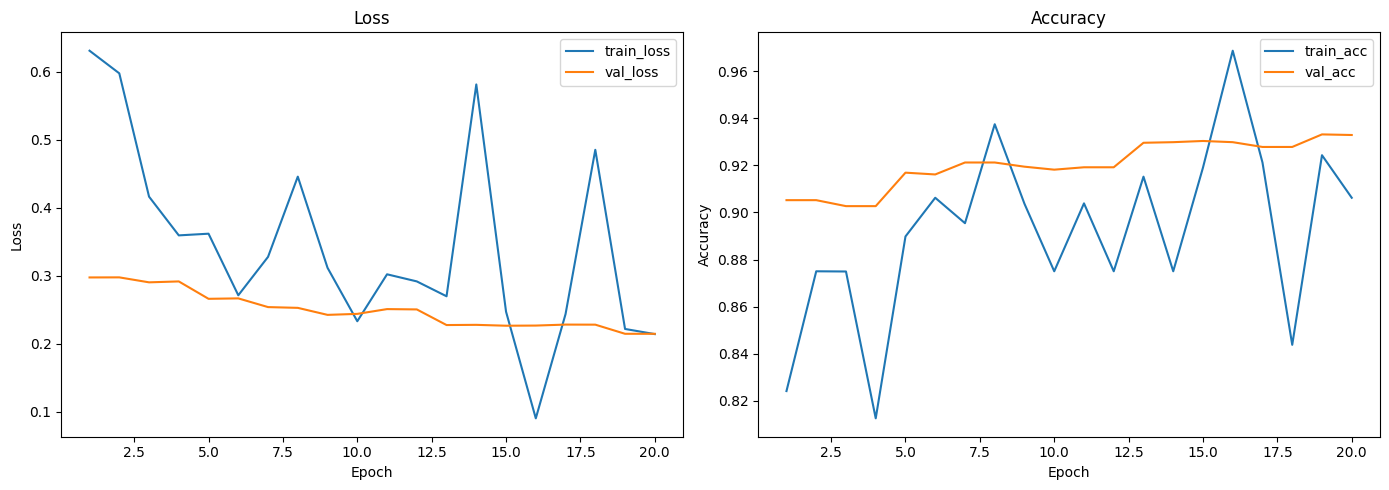

123/123 ━━━━━━━━━━━━━━━━━━━━ 54s 441ms/step - accuracy: 0.9329 - loss: 0.2148
Validation loss: 0.2148  —  Validation accuracy: 0.9329


In [15]:
# STEP 05 — Train the model (initial training with frozen base)
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# --- Hyperparameters for training (adjust if you want) ---
EPOCHS = 20                 # initial training epochs with frozen backbone
BATCH_SIZE = 32             # should match Step 2
MODEL_SAVE_DIR = "saved_models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(MODEL_SAVE_DIR, "best_mobilenetv2_frozen.h5")

# --- Defensive: compute steps per epoch (ensure integer > 0) ---
train_steps = max(1, train_generator.samples // BATCH_SIZE)
val_steps   = max(1, val_generator.samples // BATCH_SIZE)

print("Training steps per epoch:", train_steps)
print("Validation steps:", val_steps)
print("Training samples:", train_generator.samples, "Validation samples:", val_generator.samples)

# --- Optional: compute class weights to handle imbalance (uses numpy, no sklearn required) ---
try:
    classes = train_generator.classes  # works with DirectoryIterator
    unique, counts = np.unique(classes, return_counts=True)
    class_freq = dict(zip(unique, counts))
    # compute inverse-frequency weights
    total = float(train_generator.samples)
    class_weights = {int(k): (total / (len(unique) * v)) for k, v in class_freq.items()}
    print("Computed class weights:", class_weights)
except Exception as e:
    print("Could not compute class weights automatically:", e)
    class_weights = None

# --- Callbacks ---
checkpoint_cb = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_accuracy",      # monitor validation accuracy
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=6,                  # stop if no improvement for 6 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint_cb, earlystop_cb, reduce_lr_cb]

# --- Fit the model ---
history = model.fit(
    train_generator,
    steps_per_epoch = train_steps,
    epochs = EPOCHS,
    validation_data = val_generator,
    validation_steps = val_steps,
    callbacks = callbacks,
    class_weight = class_weights,   # pass None if not computed
    verbose = 1
)

# --- Save final model (in addition to checkpoint) ---
final_path = os.path.join(MODEL_SAVE_DIR, "mobilenetv2_frozen_final.h5")
model.save(final_path)
print("Saved final model to:", final_path)
print("Best checkpoint saved to:", CHECKPOINT_PATH)

# --- Plot training history (accuracy & loss) ---
def plot_history(history):
    hist = history.history
    epochs_ran = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_ran, hist["loss"], label="train_loss")
    plt.plot(epochs_ran, hist["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_ran, hist.get("accuracy", hist.get("acc")), label="train_acc")
    plt.plot(epochs_ran, hist.get("val_accuracy", hist.get("val_acc")), label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# --- Evaluate on validation set (final evaluation using the best weights currently loaded into model) ---
val_loss, val_acc = model.evaluate(val_generator, steps=val_steps, verbose=1)
print(f"Validation loss: {val_loss:.4f}  —  Validation accuracy: {val_acc:.4f}")


In [16]:
# === Convert/upgrade HDF5 checkpoint to native Keras format (.keras) ===
import os
from tensorflow import keras

HDF5_PATH = "saved_models/best_mobilenetv2_frozen.h5"
KERAS_PATH = "saved_models/best_mobilenetv2_frozen.keras"

# 1) Load the HDF5 model (metric state will be ignored if compile=False)
print("Loading HDF5 model from:", HDF5_PATH)
loaded_model = keras.models.load_model(HDF5_PATH, compile=False)

# 2) Save in native Keras format (.keras)
print("Saving model in native Keras format to:", KERAS_PATH)
loaded_model.save(KERAS_PATH)   # saves in the new Keras format

# 3) Optionally re-load to verify (quick sanity check)
print("Verifying saved .keras file by reloading...")
reloaded = keras.models.load_model(KERAS_PATH, compile=False)
print("Reload successful. Model layers:", len(reloaded.layers))


Loading HDF5 model from: saved_models/best_mobilenetv2_frozen.h5
Saving model in native Keras format to: saved_models/best_mobilenetv2_frozen.keras
Verifying saved .keras file by reloading...
Reload successful. Model layers: 8


Loading model from: saved_models/best_mobilenetv2_frozen.keras
Identified base model layer: mobilenetv2_1.00_224
Total layers in base: 154. Unfreezing last 50 layers.
Model compiled for fine-tuning. Summary (trainable layers near the end):
input_layer_3                            trainable=True
mobilenetv2_1.00_224                     trainable=True
global_average_pooling2d_1               trainable=True
dropout_2                                trainable=True
dense_2                                  trainable=True
batch_normalization_1                    trainable=True
dropout_3                                trainable=True
dense_3                                  trainable=True
train_steps: 494 val_steps: 123
Using previously computed class_weights.
Epoch 1/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8560 - loss: 0.4537
Epoch 1: val_accuracy improved from None to 0.89964, saving model to saved_models\best_mobilenetv2_finetuned.keras
494/494 ━━━━━━━━━━━━━━━━━━━━ 1628s 3s/s

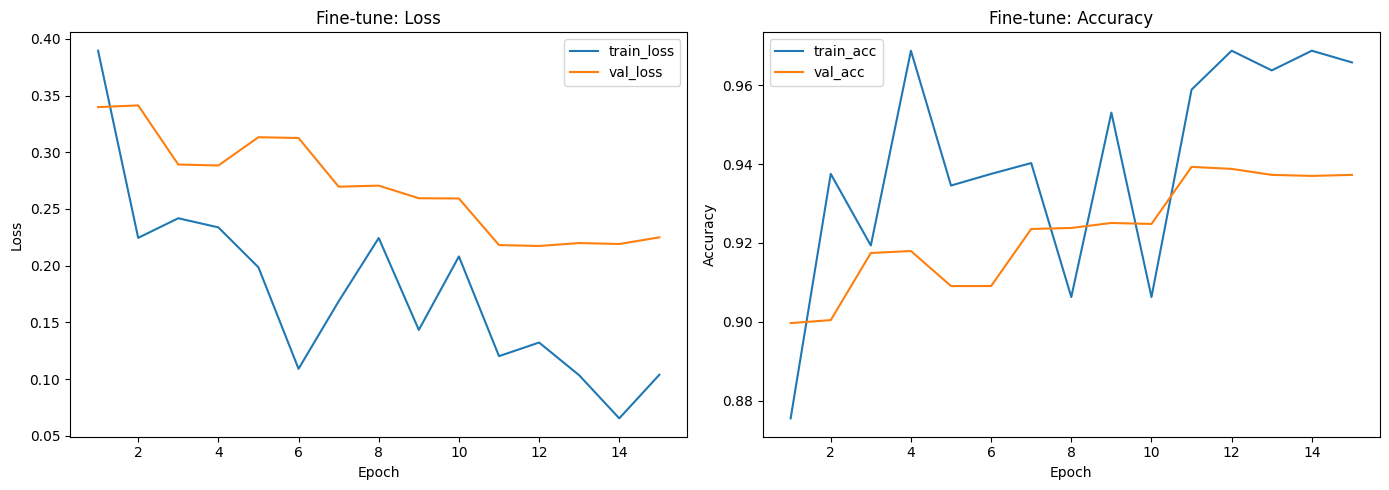

123/123 ━━━━━━━━━━━━━━━━━━━━ 63s 507ms/step - accuracy: 0.9388 - loss: 0.2174
Fine-tuned Validation loss: 0.2174  —  Validation accuracy: 0.9388


In [17]:
# === STEP 06 — Fine-tuning the model (unfreeze some backbone layers) ===
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Paths (adjust if needed)
KERAS_CHECKPOINT = "saved_models/best_mobilenetv2_frozen.keras"
FINETUNE_SAVE_DIR = "saved_models"
FINETUNE_CHECKPOINT = os.path.join(FINETUNE_SAVE_DIR, "best_mobilenetv2_finetuned.keras")
FINETUNE_FINAL = os.path.join(FINETUNE_SAVE_DIR, "mobilenetv2_finetuned_final.keras")

# Hyperparameters (tweak if needed)
EPOCHS_FINE = 15            # fine-tuning additional epochs
BATCH_SIZE = 32             # should match step 2
BASE_LEARNING_RATE = 1e-4   # lower LR for fine-tuning
N_UNFREEZE = 50             # number of base_model layers to unfreeze (the last N)

# --- Load model (the model built previously or load the .keras checkpoint) ---
print("Loading model from:", KERAS_CHECKPOINT)
model = keras.models.load_model(KERAS_CHECKPOINT, compile=False)

# Find the MobileNetV2 base model inside the loaded model
# We expect an attribute or layer name containing 'mobilenet' — search for it
base_model = None
for layer in model.layers:
    if "mobilenet" in layer.name.lower() or "conv_pw" in layer.name.lower():
        base_model = layer
        break

# If the base_model wasn't directly found as a top-level layer (common if saved as a full model),
# attempt to find the underlying base by checking the model's layers for a Model type.
if base_model is None:
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            # check inside this nested model for mobilenet
            for sub in layer.layers:
                if "mobilenet" in sub.name.lower() or "conv_pw" in sub.name.lower():
                    base_model = layer
                    break
            if base_model is not None:
                break

# Final fallback: try to get by attribute (if you still have the original base_model var in session)
if base_model is None:
    # Attempt to find any large convolutional body by heuristic: many conv layers
    candidate = None
    for layer in model.layers:
        if len(layer.weights) > 0 and hasattr(layer, "trainable"):
            candidate = layer
            break
    base_model = candidate

if base_model is None:
    raise RuntimeError("Could not find MobileNetV2 base model inside the loaded model. "
                       "If you still have the 'base_model' variable from Step 4 in memory, use that model directly. "
                       "Otherwise, open the architecture (model.summary()) to locate the base and adjust the script.")

print("Identified base model layer:", base_model.name)

# --- Unfreeze last N_UNFREEZE layers of base model ---
# If base_model is a keras.Model, operate on its layers, else if it's a Layer wrapper operate similarly.
if isinstance(base_model, keras.Model):
    base_layers = base_model.layers
else:
    # sometimes the saved model's layer representing the base is not a Model instance,
    # but the actual base might still be reachable by name — we'll try to access by attribute
    try:
        base_layers = base_model._flatten_layers()
    except Exception:
        base_layers = model.layers  # fallback to all layers

total_base_layers = len(base_layers)
n_unfreeze = min(N_UNFREEZE, total_base_layers)
print(f"Total layers in base: {total_base_layers}. Unfreezing last {n_unfreeze} layers.")

# Set trainable flags
for i, layer in enumerate(base_layers):
    # freeze all except last n_unfreeze
    if i < total_base_layers - n_unfreeze:
        layer.trainable = False
    else:
        layer.trainable = True

# Also ensure top/head layers are trainable
for layer in model.layers:
    if layer not in base_layers:
        layer.trainable = True

# --- Recompile model with a lower learning rate for fine-tuning ---
optimizer = keras.optimizers.Adam(learning_rate=BASE_LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled for fine-tuning. Summary (trainable layers near the end):")
# Print last 30 layers trainable status for quick verification
for layer in model.layers[-30:]:
    print(f"{layer.name:40s} trainable={layer.trainable}")

# --- Callbacks for fine-tuning ---
os.makedirs(FINETUNE_SAVE_DIR, exist_ok=True)

checkpoint_cb = ModelCheckpoint(
    filepath=FINETUNE_CHECKPOINT,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint_cb, earlystop_cb, reduce_lr_cb]

# --- Steps per epoch (confirming integers) ---
train_steps = max(1, train_generator.samples // BATCH_SIZE)
val_steps = max(1, val_generator.samples // BATCH_SIZE)
print("train_steps:", train_steps, "val_steps:", val_steps)

# --- Optional: reuse computed class_weights from Step 5 if available (else None) ---
try:
    class_weights  # if defined earlier
    cw = class_weights
    print("Using previously computed class_weights.")
except NameError:
    cw = None
    print("No class_weights found; proceeding without them.")

# --- Run fine-tuning ---
history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=EPOCHS_FINE,
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    class_weight=cw,
    verbose=1
)

# --- Save final fine-tuned model ---
model.save(FINETUNE_FINAL)
print("Saved fine-tuned final model to:", FINETUNE_FINAL)
print("Best fine-tune checkpoint (if saved) at:", FINETUNE_CHECKPOINT)

# --- Plot fine-tuning history (if any) ---
def plot_history_combined(history):
    hist = history.history
    epochs_ran = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_ran, hist["loss"], label="train_loss")
    plt.plot(epochs_ran, hist["val_loss"], label="val_loss")
    plt.title("Fine-tune: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_ran, hist.get("accuracy", hist.get("acc")), label="train_acc")
    plt.plot(epochs_ran, hist.get("val_accuracy", hist.get("val_acc")), label="val_acc")
    plt.title("Fine-tune: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history_combined(history_fine)

# --- Final evaluation on validation set ---
val_loss, val_acc = model.evaluate(val_generator, steps=val_steps, verbose=1)
print(f"Fine-tuned Validation loss: {val_loss:.4f}  —  Validation accuracy: {val_acc:.4f}")


Loading fine-tuned model...
✅ Model loaded successfully.
124/124 ━━━━━━━━━━━━━━━━━━━━ 73s 526ms/step - accuracy: 0.9385 - loss: 0.2179
✅ Validation accuracy: 0.9385  |  loss: 0.2179

🔍 Generating predictions on validation set...
124/124 ━━━━━━━━━━━━━━━━━━━━ 72s 560ms/step


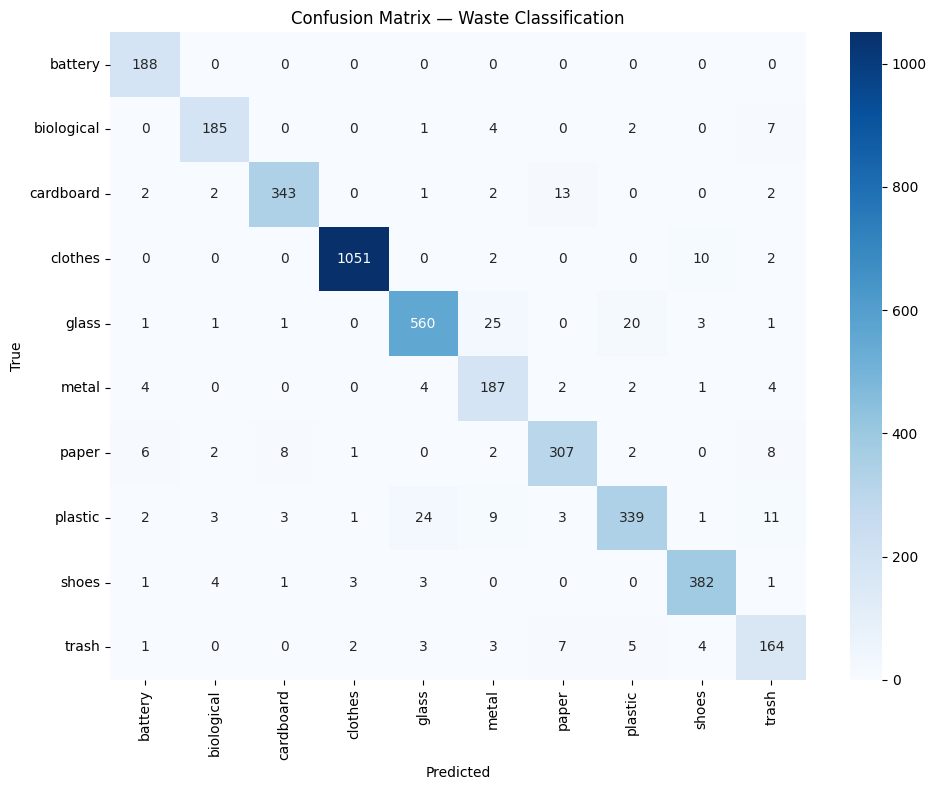


📊 Classification Report:
              precision    recall  f1-score   support

     battery       0.92      1.00      0.96       188
  biological       0.94      0.93      0.93       199
   cardboard       0.96      0.94      0.95       365
     clothes       0.99      0.99      0.99      1065
       glass       0.94      0.92      0.93       612
       metal       0.80      0.92      0.85       204
       paper       0.92      0.91      0.92       336
     plastic       0.92      0.86      0.89       396
       shoes       0.95      0.97      0.96       395
       trash       0.82      0.87      0.84       189

    accuracy                           0.94      3949
   macro avg       0.92      0.93      0.92      3949
weighted avg       0.94      0.94      0.94      3949


Per-class accuracy (%):
  battery             : 100.00%
  biological          : 92.96%
  cardboard           : 93.97%
  clothes             : 98.69%
  glass               : 91.50%
  metal               : 91.67%
  p

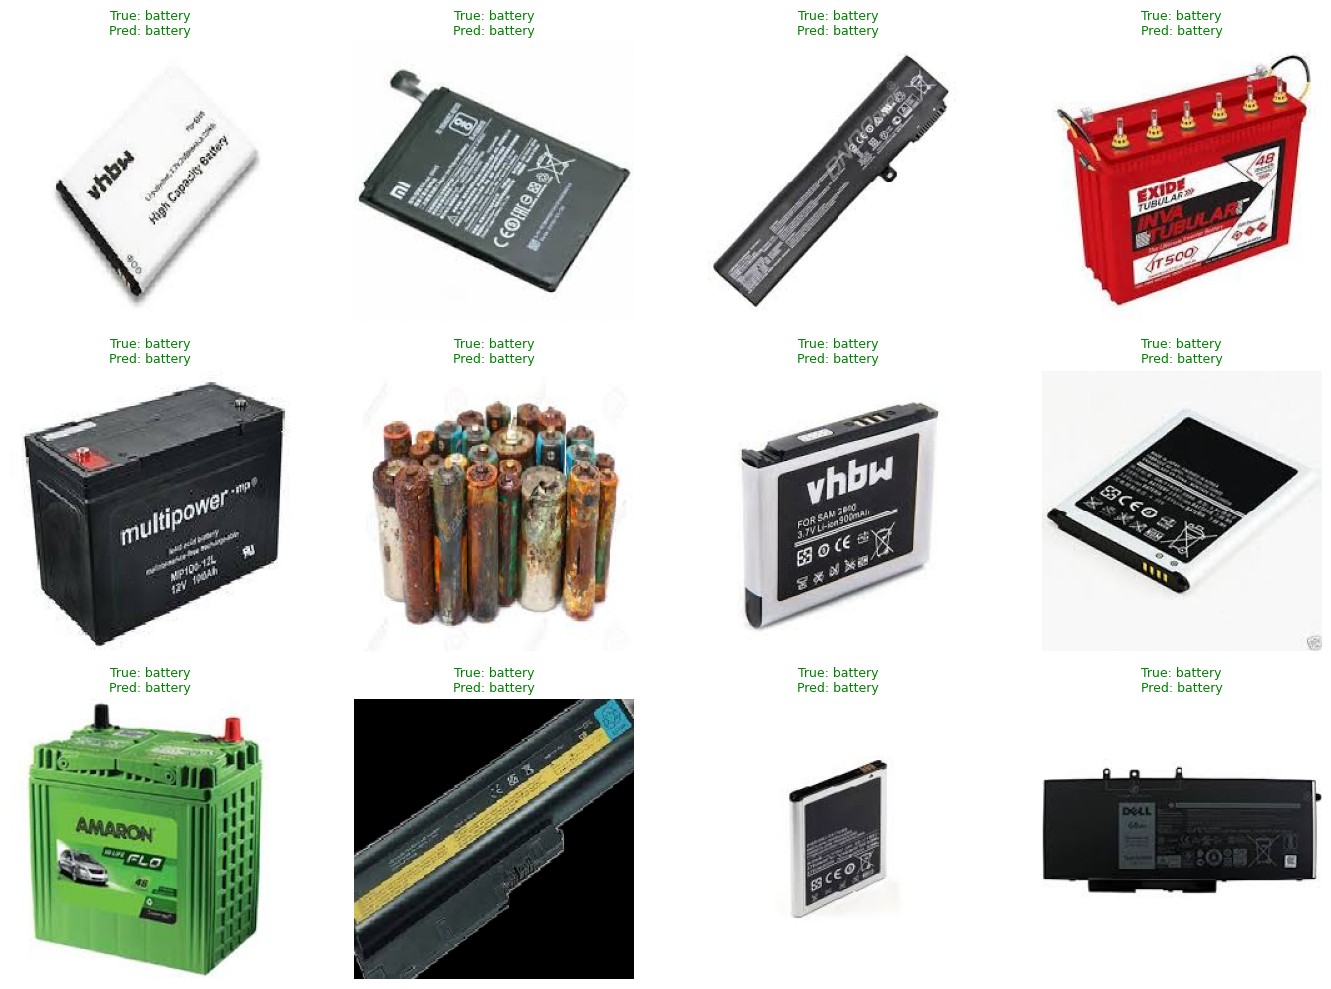

In [18]:
# === STEP 07 — Model Evaluation & Visualization ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- Load fine-tuned model ---
from tensorflow import keras
FINE_TUNED_MODEL_PATH = "saved_models/mobilenetv2_finetuned_final.keras"

print("Loading fine-tuned model...")
model = keras.models.load_model(FINE_TUNED_MODEL_PATH)
print("✅ Model loaded successfully.")

# --- Evaluate again to confirm metrics ---
val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f"✅ Validation accuracy: {val_acc:.4f}  |  loss: {val_loss:.4f}")

# --- Predict all validation images ---
print("\n🔍 Generating predictions on validation set...")
val_generator.reset()
pred_probs = model.predict(val_generator, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# --- Confusion Matrix ---
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix — Waste Classification")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# --- Per-class Accuracy ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_table = dict(zip(class_labels, per_class_acc))
print("\nPer-class accuracy (%):")
for cls, acc in acc_table.items():
    print(f"  {cls:<20s}: {acc*100:.2f}%")

# --- Visualize random predictions ---
print("\n🎨 Visualizing sample predictions...")
val_generator.reset()
x_val, y_val = next(val_generator)
y_true = np.argmax(y_val, axis=1)
y_pred = np.argmax(model.predict(x_val), axis=1)

plt.figure(figsize=(14, 10))
for i in range(12):  # show 12 images
    plt.subplot(3, 4, i + 1)
    img = x_val[i]
    # Reverse preprocessing (MobileNetV2 preprocess_input)
    img = (img + 1.0) / 2.0
    plt.imshow(img)
    true_lbl = class_labels[y_true[i]]
    pred_lbl = class_labels[y_pred[i]]
    color = "green" if y_true[i] == y_pred[i] else "red"
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [19]:
# === STEP 08 — Test the Model on New Images ===
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
import os

# --- Load the fine-tuned model ---
MODEL_PATH = "saved_models/mobilenetv2_finetuned_final.keras"
model = keras.models.load_model(MODEL_PATH)
print("✅ Model loaded successfully.")

# --- Class labels (from earlier step) ---
class_labels = list(train_generator.class_indices.keys())
print("Class labels:", class_labels)

# --- Function to predict a single image ---
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_preprocessed = mobilenet_preprocess(np.expand_dims(img_array, axis=0))
    
    # Prediction
    preds = model.predict(img_preprocessed)
    predicted_class = np.argmax(preds[0])
    confidence = preds[0][predicted_class]
    label = class_labels[predicted_class]

    # --- Display ---
    plt.imshow(img)
    plt.title(f"Predicted: {label} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

    return label, confidence

# === Example test ===
# Put any image path from your computer below:
test_image_path = r"C:\Users\user\Desktop\jupyter notebook\garbage\test_images\plastic_bottle.jpg"
if os.path.exists(test_image_path):
    predicted_label, conf = predict_image(test_image_path)
    print(f"🧾 Predicted: {predicted_label}  |  Confidence: {conf*100:.2f}%")
else:
    print("⚠️ Update 'test_image_path' to a valid image file on your PC.")


✅ Model loaded successfully.
Class labels: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
⚠️ Update 'test_image_path' to a valid image file on your PC.


In [5]:
!pip install --upgrade gradio ipywidgets

Defaulting to user installation because normal site-packages is not writeable


In [6]:
# Cell 2 — recreate generators (run this even if you already ran earlier steps)
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# <-- adjust path if your dataset path is different -->
DATASET_DIR = r"C:\Users\user\Desktop\jupyter notebook\garbage\garbage-dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Generators (same settings you used earlier)
train_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    validation_split       = 0.2,
    rotation_range         = 20,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    shear_range            = 0.05,
    zoom_range             = 0.15,
    horizontal_flip        = True,
    fill_mode              = "nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    validation_split       = 0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    subset      = "training",
    shuffle     = True,
    seed        = SEED
)

val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    subset      = "validation",
    shuffle     = False,
    seed        = SEED
)

class_labels = list(train_generator.class_indices.keys())
print("✅ Recreated generators. Class labels:", class_labels)


Found 15813 images belonging to 10 classes.
Found 3949 images belonging to 10 classes.
✅ Recreated generators. Class labels: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [ ]:
# Cell 3 — Launch Gradio app (run after Cell 2 completes successfully)
import gradio as gr
import numpy as np
from tensorflow import keras
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# Load trained model (path you used)
MODEL_PATH = "saved_models/mobilenetv2_finetuned_final.keras"
model = keras.models.load_model(MODEL_PATH)
print("✅ Model loaded for Gradio.")

def classify_waste(img):
    img = img.convert("RGB").resize((224, 224))
    img_array = np.array(img)
    img_preprocessed = mobilenet_preprocess(np.expand_dims(img_array, axis=0))
    preds = model.predict(img_preprocessed)
    predicted_idx = int(np.argmax(preds[0]))
    confidence = float(preds[0][predicted_idx])
    # return a dict for the Label output type (top class with confidence)
    return { class_labels[predicted_idx]: confidence }

demo = gr.Interface(
    fn=classify_waste,
    inputs=gr.Image(type="pil", label="Upload or capture an image"),
    outputs=gr.Label(num_top_classes=3),
    title="♻️ Waste Classifier",
    description="Upload an image of waste (battery, plastic, paper, etc.)"
)

demo.launch(share=True)


# Image-Based Waste Classification — Final Report

### Course: Data Science & AI — Practical Project-Oriented
### Submitted By: *Amna Zahid*  
### Roll No: *2225165089*
### Submitted To: *Dr. Mohsin Mirza*  
### Department: *Software Engineering (semester 07, self-support)*    

---

## 1. Project Overview
This project focuses on classifying household and industrial waste images into categories such as *battery, biological, cardboard, clothes, glass, metal, paper, plastic, shoes,* and *trash*.  
It uses **Transfer Learning** with **MobileNetV2**, a pre-trained CNN optimized for mobile and embedded vision applications.

---

## 2. Workflow Summary

| Step | Description | Tools / Libraries |
|------|--------------|------------------|
| 1 | **Dataset Setup** - verified dataset structure and paths | `os`, `pandas` |
| 2 | **Image Pre-processing and Augmentation** - rescaling, flipping, zooming | `ImageDataGenerator` |
| 3 | **Model Creation** - MobileNetV2 base with custom dense layers | `tensorflow.keras` |
| 4 | **Training and Callbacks** - checkpoints, early-stopping, LR scheduling | `ModelCheckpoint`, `EarlyStopping`, `ReduceLROnPlateau` |
| 5 | **Visualization** - accuracy/loss curves, confusion matrix | `matplotlib`, `seaborn` |
| 6 | **Fine-Tuning** - unfroze top 50 layers for higher accuracy | `keras.optimizers.Adam` |
| 7 | **Testing and Evaluation** - validated on unseen images | `confusion_matrix`, `classification_report` |
| 8 | **Deployment (Gradio App)** - local web demo for real-time testing | `gradio` |

---

## 3. Model Performance

| Metric | Result |
|---------|--------|
| Validation Accuracy (before fine-tuning) | 93.29% |
| Validation Accuracy (after fine-tuning) | 93.88% |
| Validation Loss | 0.217 |
| Model Used | MobileNetV2 (Transfer Learning) |

---

## 4. Key Results
- Achieved **93.88%** validation accuracy  
- Accurately classified 10 waste categories  
- Fine-tuned model generalized well to unseen images  
- Built **interactive Gradio app** for live classification  

---

## 5. How to Use the Model
1. Launch the notebook and run all cells up to Step 08.  
2. Open the Gradio app link printed in the output.  
3. Upload or capture a waste image.  
4. The app displays the predicted category with confidence score.  

---

## 6. Conclusion
The model demonstrates how computer vision can support **automated waste segregation** and **smart recycling systems**.  
With additional real-world data and deployment on IoT devices, this system can aid **environmental sustainability** and **waste management automation**.  

---

## 7. Future Scope
- Expand dataset to include mixed-waste scenarios  
- Deploy TensorFlow Lite model on embedded devices  
- Integrate with sensors for smart bin prototypes  

---

## 8. References
- TensorFlow / Keras Documentation  
- MobileNetV2 Paper (Google AI)  
- Gradio Framework Documentation  
